In [1]:
import pandas as pd

In [3]:
df=pd.read_csv("newdataset/train.csv")

In [ ]:
df.head();


In [6]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  str    
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  str    
 6   weather                 517754 non-null  str    
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  str    
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13  accident_risk           517754 non-null  float64
dtypes: bool(4), float64(2), int64(4

In [7]:
df.head()


,id,road_type,num_lanes,curvature,speed_limit,lighting,weather,road_signs_present,public_road,time_of_day,holiday,school_season,num_reported_accidents,accident_risk
0,0,urban,2,0.06,35,daylight,rainy,False,True,afternoon,False,True,1,0.13
1,1,urban,4,0.99,35,daylight,clear,True,False,evening,True,True,0,0.35
2,2,rural,4,0.63,70,dim,clear,False,True,morning,True,False,2,0.30
3,3,highway,4,0.07,35,dim,rainy,True,True,morning,False,False,1,0.21
4,4,rural,1,0.58,60,daylight,foggy,False,False,evening,True,False,1,0.56


In [8]:
df.describe() 

,id,num_lanes,curvature,speed_limit,num_reported_accidents,accident_risk
count,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000,517754.000000
mean,258876.500000,2.491511,0.488719,46.112575,1.187970,0.352377
std,149462.849975,1.120434,0.272563,15.788521,0.895961,0.166417
min,0.000000,1.000000,0.000000,25.000000,0.000000,0.000000
25%,129438.250000,1.000000,0.260000,35.000000,1.000000,0.230000
50%,258876.500000,2.000000,0.510000,45.000000,1.000000,0.340000
75%,388314.750000,3.000000,0.710000,60.000000,2.000000,0.460000
max,517753.000000,4.000000,1.000000,70.000000,7.000000,1.000000


In [9]:
df.isnull().sum()

id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64

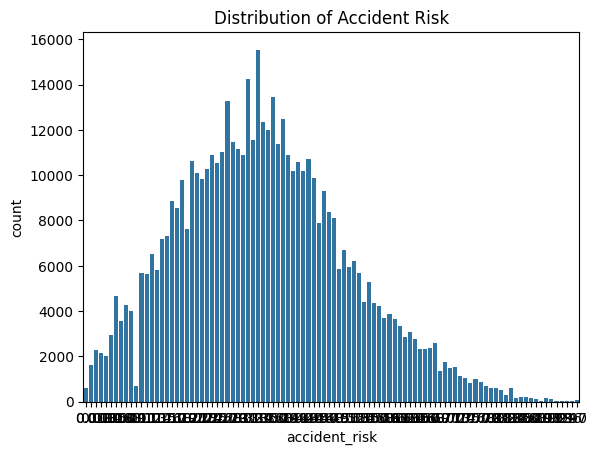

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="accident_risk", data=df)
plt.title("Distribution of Accident Risk")
plt.show()

Encode Categorical Data
Encoding Categorical Data is where you convert non-numeric columns into numbers so models like XGBoost can understand them.

🔍 Why Encoding is Needed

Machine learning models don’t understand text like:

weather = sunny
road_type = highway

They only understand numbers, so we convert categories → numeric form.

Label Encoding (For ordered data)

Used when categories have meaning/order.

Example:

low < medium < high


One-Hot Encoding (Most common for your case ✅)

Used when categories have no order

Example:

weather: sunny, rainy, foggy

Becomes:

weather_sunny   weather_rainy   weather_foggy
      1                0                0

In [16]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object'):
    df_encoded[col] = le.fit_transform(df_encoded[col])

C:\Users\kisha\AppData\Local\Temp\ipykernel_3512\640987402.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_encoded.select_dtypes(include='object'):


In [17]:
corr = df_encoded.corr()

In [18]:
corr["accident_risk"].sort_values(ascending=False)

accident_risk             1.000000
curvature                 0.543946
speed_limit               0.430898
lighting                  0.393860
num_reported_accidents    0.213891
weather                   0.130064
holiday                   0.051129
public_road               0.031032
road_type                 0.018899
id                        0.000969
road_signs_present        0.000629
school_season            -0.000977
time_of_day              -0.001165
num_lanes                -0.006003
Name: accident_risk, dtype: float64

STEP 7: Heatmap Visualization

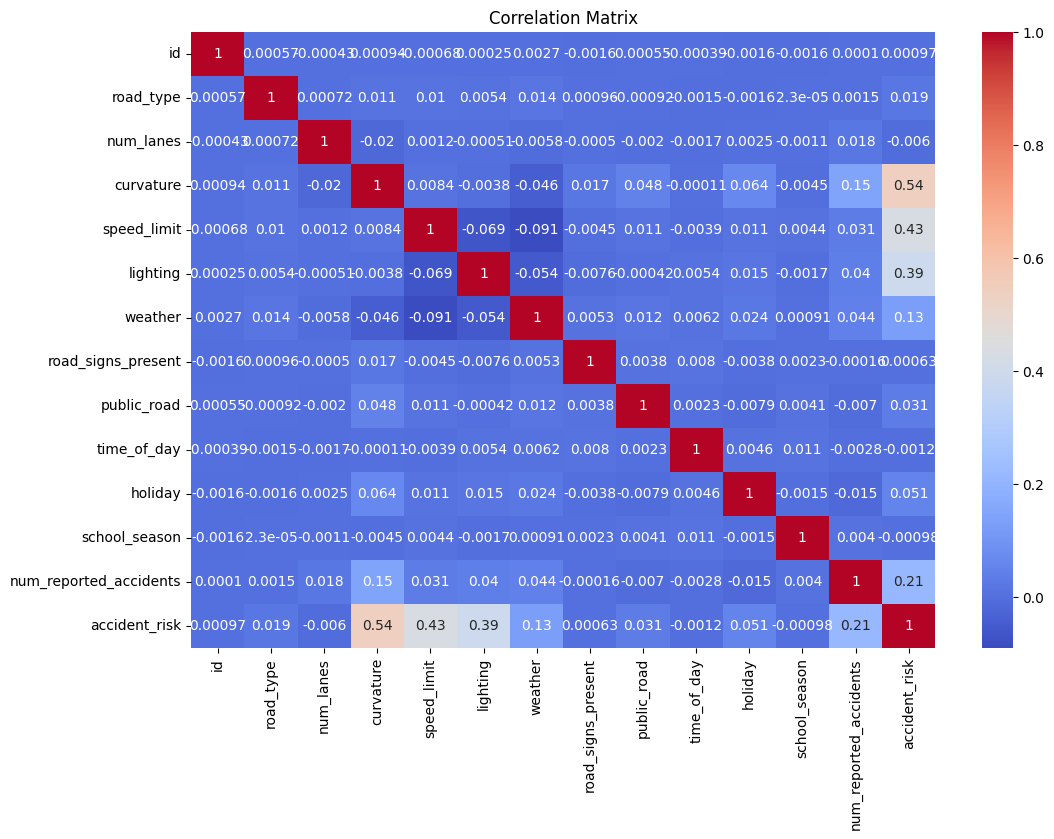

In [21]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

1. Speed Limit vs Risk

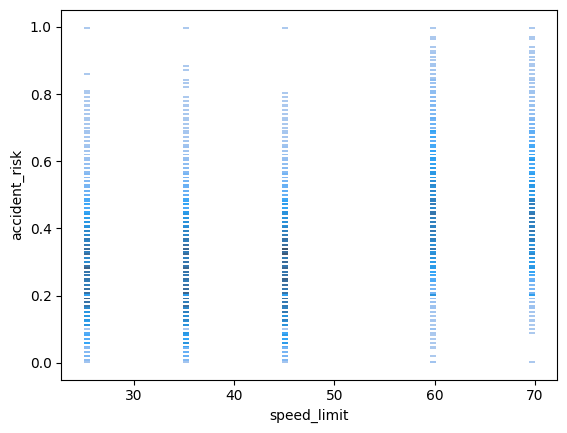

In [28]:
sns.histplot(x="speed_limit", y="accident_risk", data=df)
plt.show()


2. Weather vs Risk

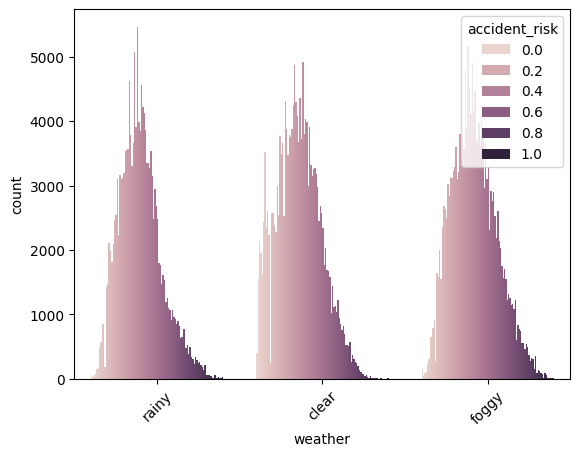

In [27]:
sns.countplot(x="weather", hue="accident_risk", data=df)
plt.xticks(rotation=45)
plt.show()

time of the day

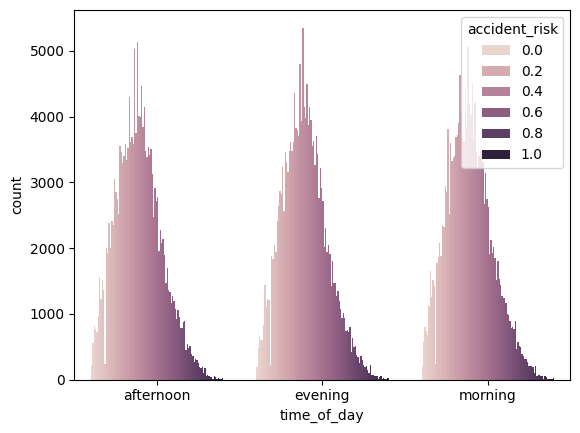

In [30]:
sns.countplot(x="time_of_day",hue="accident_risk",data=df)
plt.show()

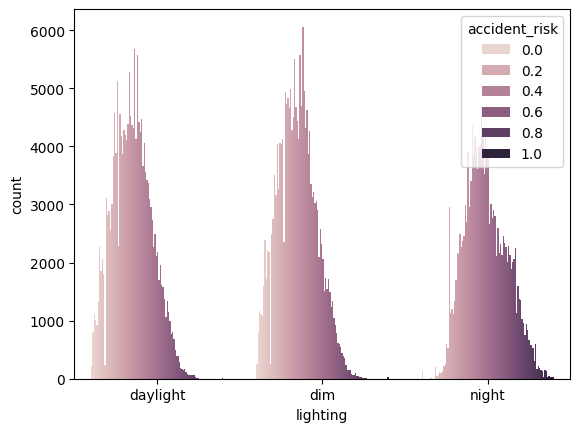

In [31]:
sns.countplot(x="lighting",hue="accident_risk",data=df)
plt.show()

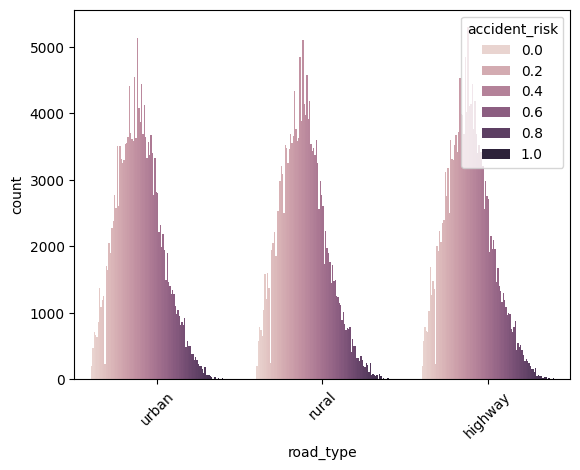

In [32]:
sns.countplot(x="road_type", hue="accident_risk", data=df)
plt.xticks(rotation=45)
plt.show()

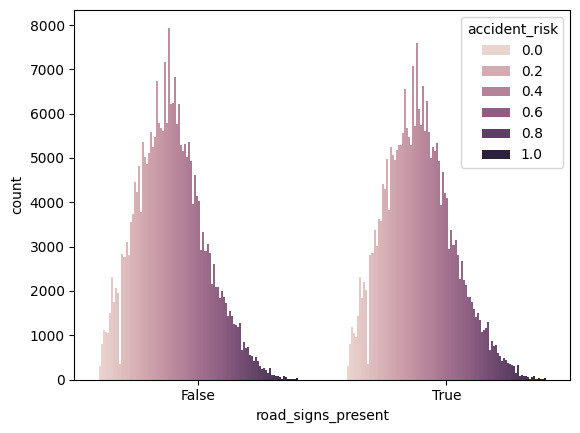

In [33]:
sns.countplot(x="road_signs_present", hue="accident_risk", data=df)
plt.show()

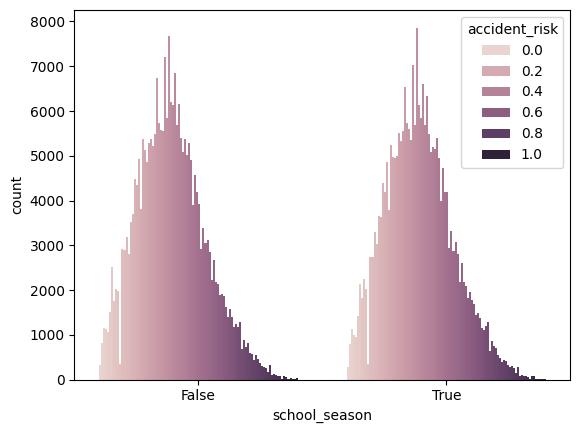

In [34]:
sns.countplot(x="school_season", hue="accident_risk", data=df)
plt.show()

NameError: name 'model' is not defined

In [36]:
corr["accident_risk"].sort_values(ascending=False)

accident_risk             1.000000
curvature                 0.543946
speed_limit               0.430898
lighting                  0.393860
num_reported_accidents    0.213891
weather                   0.130064
holiday                   0.051129
public_road               0.031032
road_type                 0.018899
id                        0.000969
road_signs_present        0.000629
school_season            -0.000977
time_of_day              -0.001165
num_lanes                -0.006003
Name: accident_risk, dtype: float64